# Customer Churn Prediction
Data Engineering and Simple Model

I worked witha telecommunications customer dataset to predict wheather a customer is likely to churn (leave the company), based on their account information and useage patterns.

To be able to identify customers who may leave can be valuable for a business because retaining existing customers can be more cost effective than finding new ones. By predicting churn earlier, a company can take action through targeted offers, better service, or other strategies to improve customer retention.

Data Loading

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("customer_churn.csv")

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   CUST2272    Male              0     Yes         No    10.0          Yes   
1   CUST2877    Male              0      No         No    35.0          Yes   
2   CUST3838  Female              0     Yes        Yes    13.0          Yes   
3   CUST3857  Female              0      No         No    24.0          Yes   
4   CUST6654    Male              0      No         No    13.0          Yes   

  MultipleLines InternetService       OnlineSecurity  ...  \
0           Yes              No  No internet service  ...   
1            No     Fiber optic                  Yes  ...   
2            No     Fiber optic                  Yes  ...   
3            No              No  No internet service  ...   
4            No             DSL                  Yes  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0  No internet service  No internet service  No internet serv

In [2]:
print(f"Dataset shape: {df.shape}")
print("\nDataset information:")
df.info()

Dataset shape: (7183, 21)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7183 entries, 0 to 7182
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7183 non-null   object 
 1   gender            7183 non-null   object 
 2   SeniorCitizen     7183 non-null   int64  
 3   Partner           7183 non-null   object 
 4   Dependents        7183 non-null   object 
 5   tenure            7077 non-null   float64
 6   PhoneService      7183 non-null   object 
 7   MultipleLines     7183 non-null   object 
 8   InternetService   7183 non-null   object 
 9   OnlineSecurity    7183 non-null   object 
 10  OnlineBackup      7183 non-null   object 
 11  DeviceProtection  7183 non-null   object 
 12  TechSupport       7183 non-null   object 
 13  StreamingTV       7183 non-null   object 
 14  StreamingMovies   7183 non-null   object 
 15  Contract          7183 non-null   object 

In [3]:
print("Summary statistics:")
df.describe()

Summary statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7183.000000,7077.000000,7075.000000
mean,0.159404,19.341105,88.139980
std,0.366078,13.951658,37.726709
min,0.000000,1.000000,20.000000
25%,0.000000,9.000000,63.090000
50%,0.000000,16.000000,89.130000
75%,0.000000,26.000000,121.160000
max,1.000000,72.000000,177.280000


In [4]:
assert df is not None, "DataFrame 'df' is not loaded"
assert isinstance(df, pd.DataFrame), "'df' must be a pandas DataFrame"
assert len(df) > 0, "DataFrame is empty"
assert 'Churn' in df.columns, "Target column 'Churn' not found"
print("✓ Part 1 tests passed!")

✓ Part 1 tests passed!


Data Exploration

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("Churn distribution:")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print("\nChurn percentages:")
print(churn_counts / len(df))

Churn distribution:
Churn
No     4146
Yes    3037
Name: count, dtype: int64

Churn percentages:
Churn
No     0.577196
Yes    0.422804
Name: count, dtype: float64


In [7]:
print("Missing values:")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df))*100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percent': missing_percent
})
print(missing_df[missing_df['Missing_Count'] > 0])

Missing values:
                Missing_Count  Missing_Percent
tenure                    106         1.475707
MonthlyCharges            108         1.503550


In [8]:
assert churn_counts is not None,"Churn counts not calculated"
assert missing_values is not None, "Missing values not calculated"
assert missing_percent is not None, "Missing percentages not calculated"
print("✓ Part 2 tests passed!")


✓ Part 2 tests passed!


Data Cleaning

In [12]:
def clean_data(df):
    """
    Clean the input DataFrame by:
    1. Removing duplicate rows
    2. Handling missing values appropriately
    3. Converting data types as needed

    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame to clean

    Returns:
    --------
    pandas.DataFrame
        The cleaned DataFrame
    """

    df_clean = df.copy()

    df_clean = df_clean.drop_duplicates()

     # numerical and categorical columns
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(include=['object']).columns

    # missing values in numerical columns with median
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
          df_clean[col] = df_clean[col].fillna(df_clean[col].median())


    for col in categorical_cols:
      if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


    if 'TotalCharges' in df_clean.columns:
      df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
      df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())
      pass

    return df_clean


df_clean = clean_data(df)
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"\nMissing values after cleaning: {df_clean.isnull().sum().sum()}")


Original dataset shape: (7183, 21)
Cleaned dataset shape: (7183, 21)

Missing values after cleaning: 0


In [13]:
assert df_clean is not None, "Cleaned DataFrame not created"
assert df_clean.isnull().sum().sum() == 0, "Missing values still present after cleaning"
assert len(df_clean) <= len(df), "Cleaned dataset should not have more rows than original"
print("✓ Part 3 tests passed!")

✓ Part 3 tests passed!


Feature Engineering

In [15]:
from sklearn.preprocessing import LabelEncoder

def prepare_features(df):
    """
    Prepare features for modeling by:
    1. Encoding categorical variables
    2. Separating features (X) and target (y)

    Parameters:
    -----------
    df : pandas.DataFrame
        The cleaned DataFrame

    Returns:
    --------
    tuple: (X, y)
        X: Features DataFrame
        y: Target Series
    """
    df_encoded = df.copy()


    binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
    for col in binary_cols:
        if col in df_encoded.columns:
            df_encoded[col] = df_encoded[col].replace({'Yes': 1, 'No': 0})
            pass


    categorical_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in categorical_cols:
        if col in df_encoded.columns:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col])
            pass

    if 'customerID' in df_encoded.columns:
        df_encoded = df_encoded.drop('customerID', axis=1)

    X = df_encoded.drop('Churn', axis = 1)
    y = df_encoded['Churn']

    return X, y

X, y = prepare_features(df_clean)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (7183, 19)
Target shape: (7183,)

Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


/tmp/ipykernel_489/1957140883.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded[col] = df_encoded[col].replace({'Yes': 1, 'No': 0})


In [16]:
assert X is not None and y is not None, "Features or target not created"
assert len(X) == len(y), "Features and target must have same number of rows"
assert 'Churn' not in X.columns, "Target column should not be in features"
assert 'customerID' not in X.columns, "customerID should not be in features"

assert X.select_dtypes(include=[np.number]).shape[1] == X.shape[1], "All features must be numeric"
print("✓ Part 4 tests passed!")

✓ Part 4 tests passed!


Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42) # YOUR CODE HERE

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print(f"\nTraining set churn distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTesting set churn distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 5746 samples
Testing set size: 1437 samples

Training set churn distribution:
Churn
0    0.578663
1    0.421337
Name: proportion, dtype: float64

Testing set churn distribution:
Churn
0    0.571329
1    0.428671
Name: proportion, dtype: float64


In [18]:
assert X_train is not None and X_test is not None, "Training or testing features not created"
assert y_train is not None and y_test is not None, "Training or testing target not created"
assert len(X_train) > len(X_test), "Training set should be larger than testing set"
assert len(X_train) + len(X_test) == len(X), "Train + test should equal original dataset size"
assert abs(len(X_train) / len(X) - 0.8) < 0.01, "Training set should be approximately 80% of data"
print("✓ Part 5 tests passed!")

✓ Part 5 tests passed!


Model Training

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state = 42, max_iter =1000)
model.fit(X_train_scaled, y_train)

print("Model training complete!")
print(f"Model type: {type(model).__name__}")

Model training complete!
Model type: LogisticRegression


In [20]:
assert scaler is not None, "Scaler not created"
assert X_train_scaled is not None and X_test_scaled is not None, "Scaled data not created"
assert model is not None, "Model not created"
assert hasattr(model, 'coef_'), "Model not trained (no coefficients found)"
print("✓ Part 6 tests passed!")

✓ Part 6 tests passed!


Model Evaluation

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Performance Metrics:
Accuracy: 0.6576
Precision: 0.6131
Recall: 0.5455
F1-Score: 0.5773

Confusion Matrix:
[[609 212]
 [280 336]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.74      0.71       821
           1       0.61      0.55      0.58       616

    accuracy                           0.66      1437
   macro avg       0.65      0.64      0.64      1437
weighted avg       0.65      0.66      0.65      1437



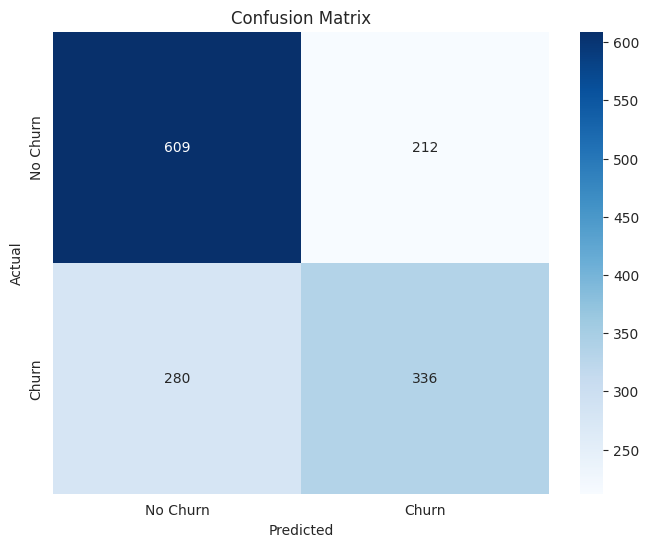

In [22]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [23]:
# Test: Check model evaluation
assert y_pred is not None, "Predictions not made"
assert len(y_pred) == len(y_test), "Predictions length must match test set length"
assert accuracy is not None, "Accuracy not calculated"
assert precision is not None, "Precision not calculated"
assert recall is not None, "Recall not calculated"
assert f1 is not None, "F1-score not calculated"
assert cm is not None, "Confusion matrix not created"
assert 0 <= accuracy <= 1, "Accuracy must be between 0 and 1"
assert 0 <= precision <= 1, "Precision must be between 0 and 1"
assert 0 <= recall <= 1, "Recall must be between 0 and 1"
assert 0 <= f1 <= 1, "F1-score must be between 0 and 1"
print("✓ Part 7 tests passed!")

✓ Part 7 tests passed!
